(12)=
# Chapter 12: Polynomial Fitting

**Topics Covered:**
- Polynomial basics: `np.poly1d`, `np.polyval`, `np.polyfit`
- Least-squares polynomial fitting: choosing the right degree, residuals, $R^2$

In [2]:
# ── All imports ─────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

(12.1)=
## 12.1 Motivation: Heat Capacity of CO$_2$

In chemical engineering, we frequently need $C_p(T)$ — the molar heat capacity as a function of temperature — to compute:

$$
Q = n \int_{T_1}^{T_2} C_p(T)\, dT
$$

NIST publishes $C_p$ in tabulated form at discrete temperatures. Before we can integrate, we need a **continuous mathematical model** — a polynomial — that passes smoothly through the data.

Below is a subset of NIST data for CO$_2$ (ideal gas, J mol$^{-1}$ K$^{-1}$):

| $T$ (K) | $C_p$ (J mol$^{-1}$ K$^{-1}$) |
|---------|-------------------------------|
| 300     | 37.13                         |
| 400     | 41.33                         |
| 500     | 44.60                         |
| 600     | 47.33                         |
| 700     | 49.65                         |
| 800     | 51.61                         |
| 900     | 53.26                         |
| 1000    | 54.31                         |
| 1100    | 55.37                         |
| 1200    | 56.21                         |

We want to fit $C_p(T) \approx a_0 + a_1 T + a_2 T^2 + \cdots$ so we can evaluate it at any temperature and integrate it analytically.

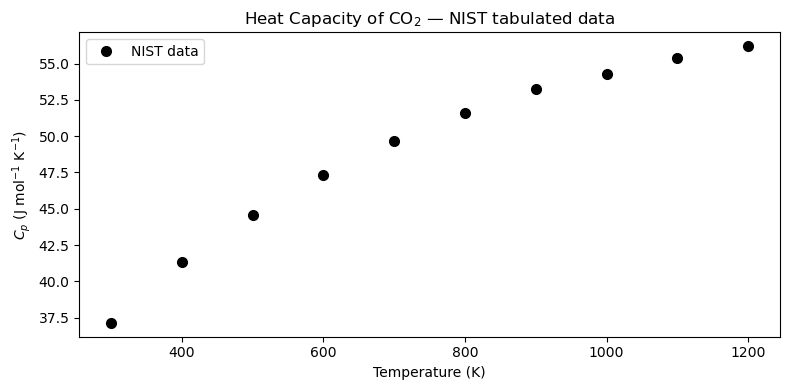

In [26]:
# NIST tabulated Cp data for CO2 (ideal gas)
T_data  = np.array([300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200], dtype=float)  # K
Cp_data = np.array([37.13, 41.33, 44.60, 47.33, 49.65,
                    51.61, 53.26, 54.31, 55.37, 56.21])  # J/(mol K)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T_data, Cp_data, 'ko', markersize=7, label='NIST data')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$C_p$ (J mol$^{-1}$ K$^{-1}$)')
ax.set_title(r'Heat Capacity of CO$_2$ — NIST tabulated data')
ax.legend()
plt.tight_layout()
plt.show()

(12.2)=
## 12.2 Polynomial Basics

A degree-$n$ polynomial is:

$$
p(x) = a_n x^n + a_{n-1} x^{n-1} + \cdots + a_1 x + a_0
$$

NumPy stores polynomial coefficients in **descending order** (highest power first). Three key tools:

| Function | Purpose |
|----------|---------|
| `np.poly1d(coeffs)` | Create a callable polynomial object |
| `np.polyval(coeffs, x)` | Evaluate polynomial at $x$ |
| `np.polyfit(x, y, deg)` | Least-squares fit: returns coefficients |

**Convention:** `coeffs = [a_n, a_{n-1}, ..., a_1, a_0]` — highest power first.

---

### The coefficient array

Say you have $p(x) = 3x^2 + 5x - 2$. NumPy represents this as `[3, 5, -2]`:

```
index:  0    1    2
value: [3,   5,  -2]
         ↑    ↑    ↑
        x²   x¹   x⁰
```

### `np.poly1d(coeffs)` — callable polynomial object

Wraps the coefficient list into an object you can call like a function:
```python
p = np.poly1d([3, 5, -2])
p(1)   # → 3(1)² + 5(1) - 2 = 6
p(0)   # → -2
```
Bonus methods: `p.deriv()` (derivative), `p.integ()` (integral), `p.roots` (zeros).

### `np.polyval(coeffs, x)` — evaluate from the list directly

Same result, no object needed. Works on scalars or arrays:
```python
np.polyval([3, 5, -2], 1)           # → 6
np.polyval([3, 5, -2], [0, 1, 2])   # → [-2, 6, 20]
```
Use this when you only need values and don't need derivatives/integrals.

### `np.polyfit(x, y, deg)` — find best-fit coefficients

Given data points, returns a coefficient array in the same descending convention:
```python
coeffs = np.polyfit(x_data, y_data, deg=3)  # fit  → coeffs
p      = np.poly1d(coeffs)                  # wrap → callable
y_fit  = p(x_fine)                          # evaluate on dense grid
# or equivalently:
y_fit  = np.polyval(coeffs, x_fine)
```

Use `poly1d` when you also need `.deriv()` / `.integ()` / `.roots`; use `polyval` when you just need numbers.

In [27]:
# ── Coefficient convention demo ───────────────────────────────────────────
# p(x) = 3x² + 5x - 2   →   coeffs = [3, 5, -2]  (descending order)
coeffs_demo = [3, 5, -2]

p_demo = np.poly1d(coeffs_demo)
print("poly1d pretty-print:")
print(p_demo)

print("-----manual input-------")
print(p_demo(0))
print(p_demo(1))
print(p_demo(2))
print(p_demo(3))
print("------polyval---------")
print(np.polyval(coeffs_demo, [0,1,2,3]))


poly1d pretty-print:
   2
3 x + 5 x - 2
-----manual input-------
-2
6
20
40
------polyval---------
[-2  6 20 40]


In [28]:
# Define p(x) = 2x^3 - 3x^2 + x - 5  (coefficients in descending order)
coeffs = [2, -3, 1, -5]

p = np.poly1d(coeffs)
print("Polynomial p(x):")

print(p)




Polynomial p(x):
   3     2
2 x - 3 x + 1 x - 5


(200,)
(200,)


Text(0, 0.5, 'p(x)')

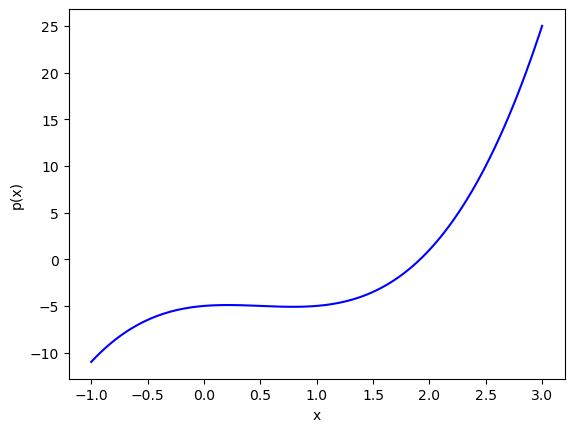

In [29]:
# Plot the polynomial over [-1, 3]
x = np.linspace(-1, 3, 200)
y = np.polyval(coeffs, x)


print(x.shape)
print(y.shape)

# fig, ax = plt.subplots(figsize=(8,4))
plt.plot(x, y, 'b-')
plt.xlabel('x')
plt.ylabel('p(x)')

(12.3)=
## 12.3 Least-Squares Polynomial Fitting

**`np.polyfit(x, y, deg)`** finds the degree-`deg` polynomial coefficients that minimize the sum of squared residuals:

$$
\min_{a_0, \ldots, a_n} \sum_{i=1}^{N} \left[ y_i - p(x_i) \right]^2
$$

This is ordinary least squares applied to a polynomial basis. The function returns coefficients in descending order (highest power first), just like `np.poly1d` expects.

(12.3.1)=
### 12.3.1 Fitting Cp(T) with Different Degrees

We fit the CO$_2$ data with degree 1, 2, and 3 polynomials and compare the results visually.

In [19]:
T_data, Cp_data

(array([ 300.,  400.,  500.,  600.,  700.,  800.,  900., 1000., 1100.,
        1200.]),
 array([37.13, 41.33, 44.6 , 47.33, 49.65, 51.61, 53.26, 54.31, 55.37,
        56.21]))

[2.05030303e-02 3.37027273e+01]
[-1.98030303e-05  5.02075758e-02  2.41972727e+01]


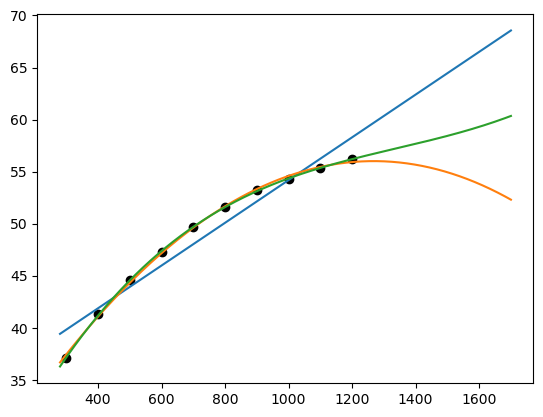

In [30]:
# ── Fit Cp(T) with degree 1, 2, 3 polynomials ────────────────────────────────

T_fine = np.linspace(280, 1700, 300)

coeffs_deg1 = np.polyfit(T_data, Cp_data, 1)
coeffs_deg2 = np.polyfit(T_data, Cp_data, 2)
coeffs_deg3 = np.polyfit(T_data, Cp_data, 3)
print(coeffs_deg1) # Cp = 2.05030303e-02 T + 3.37027273e+01
print(coeffs_deg2) # Cp = -1.98030303e-05 T^2 + 5.02075758e-02 T + 2.41972727e+01
Cp_deg1 = np.polyval(coeffs_deg1, T_fine)
Cp_deg2 = np.polyval(coeffs_deg2, T_fine)
Cp_deg3 = np.polyval(coeffs_deg3, T_fine)

plt.plot(T_data, Cp_data, 'ko')
plt.plot(T_fine, Cp_deg1)
plt.plot(T_fine, Cp_deg2)
plt.plot(T_fine, Cp_deg3)


The residual $e_i$ is the vertical distance between a measured data point and the model's prediction at that same $x$:

$$
e_i = y_i - p(x_i)
$$

A positive residual means the model underpredicts; negative means it overpredicts. A good fit has residuals that are small and scattered randomly around zero.

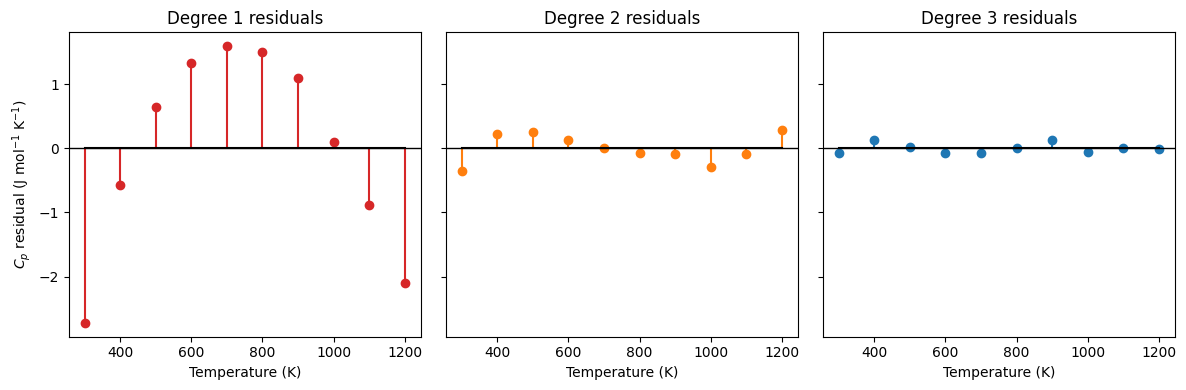

In [28]:
# ── Residual stem plots for each degree ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
degrees = [1, 2, 3]
colors  = ['tab:red', 'tab:orange', 'tab:blue']
fits    = {}    # store coefficient arrays keyed by degree

for deg in degrees:
    fits[deg] = np.polyfit(T_data, Cp_data, deg)

for ax, deg, color in zip(axes, degrees, colors):
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    ax.stem(T_data, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_xlabel('Temperature (K)')
    ax.set_title(f'Degree {deg} residuals')

axes[0].set_ylabel(r'$C_p$ residual (J mol$^{-1}$ K$^{-1}$)')
plt.tight_layout()
plt.show()

(12.3.2)=
### 12.3.2 Fit Quality Metrics: MAE, MSE, and $R^2$

Given residuals $e_i = y_i - p(x_i)$, where:
- $y_i$ — observed (measured) value at point $i$
- $p(x_i)$ — model-predicted value at the same point $x_i$

three standard metrics quantify how well the model fits the data:

$$
\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |e_i|
\qquad
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} e_i^2
\qquad
R^2 = 1 - \frac{\sum_i e_i^2}{\sum_i (y_i - \bar{y})^2}
$$

| Metric | Full name | Units | Interpretation |
|--------|-----------|-------|----------------|
| **MAE** | Mean Absolute Error | same as $y$ | Average magnitude of error; easy to interpret |
| **MSE** | Mean Squared Error | $y^2$ | Penalizes large errors more heavily; used by least-squares optimization |
| **$R^2$** | Coefficient of Determination | dimensionless | Fraction of variance explained by the model; 1 = perfect |

**Why square in MSE (and not just use MAE)?**
- **Penalize large errors more heavily** — an error of 2 contributes 4× more than an error of 1; the fit is driven by the worst offenders
- **Smooth, differentiable objective** — $e_i^2$ has a clean derivative everywhere, which is what allows least-squares to be solved analytically; $|e_i|$ is not differentiable at zero

**Interpreting $R^2$:** Here $\bar{y} = \frac{1}{N}\sum_i y_i$ is the mean of all measured values — the "dumbest possible prediction" (just guess the average every time). The denominator $\sum_i(y_i - \bar{y})^2$ is how much the data varies around that mean (total spread). The numerator $\sum_i e_i^2$ is the variance your model *failed* to explain. Subtracting their ratio from 1 gives the fraction the model *does* explain. If the model only predicted $\bar{y}$ for every point, $R^2 = 0$; a perfect fit gives $R^2 = 1$.

- $R^2 = 1$ — perfect fit; every residual is zero
- $R^2 = 0$ — the model does no better than just predicting $\bar{y}$ for every point
- $R^2 < 0$ — the model is worse than the mean (a sign something is seriously wrong)

2.0
variance of residuals (model error):  1.0
variance of true values (data variability): 1.0
R2: 0.0


Text(0.5, 0, 'Pred')

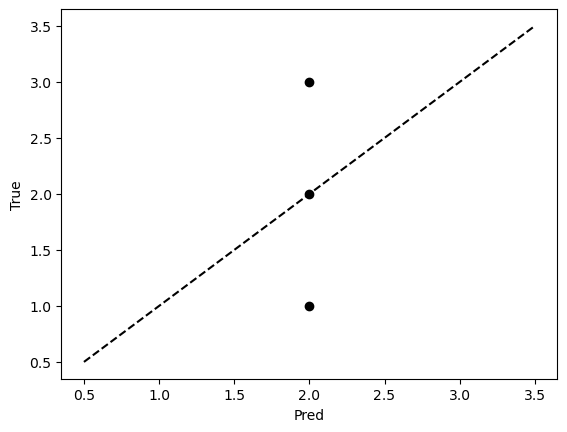

In [23]:
import numpy as np
import matplotlib.pyplot as plt

true = np.array([1, 2,  3])
mean = np.mean(true)
print(mean)
pred = np.array([mean, mean, mean])#np.array([1.1, 1.7, 3.2])
 

residuals = true - pred

# print("Residuals :", residuals)

# print("MAE: ", np.mean(abs(residuals)))
# print("MSE: ", np.mean(residuals**2))

# numerator - variance of residuals
residual_variance = np.var(residuals, ddof=1)
print("variance of residuals (model error): ", residual_variance)

# denominator - variance of true values (data points that we want to fit) 
true_variance = np.var(true, ddof=1)
print("variance of true values (data variability):", true_variance)


R2 = 1 - residual_variance / true_variance

print(f"R2: {R2}")


plt.plot(pred, true, 'ko')
plt.plot([0.5, 3.5], [0.5, 3.5], 'k--')
plt.ylabel('True')
plt.xlabel('Pred')

In [10]:
import numpy as np
# ── MAE, MSE, R² for each polynomial degree ──────────────────────────────────
SS_tot = np.sum((Cp_data - np.mean(Cp_data))**2)

print(f"{'Degree':>6}  {'MAE':>18}  {'MSE':>18}  {'R²':>10}")
print(f"{'':>6}  {'(J/mol/K)':>18}  {'(J/mol/K)²':>18}  {'':>10}")
print("-" * 60)
for deg in degrees:
    Cp_pred   = np.polyval(fits[deg], T_data)
    residuals = Cp_data - Cp_pred
    MAE = np.mean(np.abs(residuals))
    MSE = np.mean(residuals**2)
    R2  = 1.0 - np.sum(residuals**2) / SS_tot
    print(f"{deg:>6}  {MAE:>18.6f}  {MSE:>18.6f}  {R2:>10.6f}")

Degree                 MAE                 MSE          R²
                 (J/mol/K)          (J/mol/K)²            
------------------------------------------------------------
     1            1.256000            2.114124    0.942543
     2            0.179212            0.043519    0.998817
     3            0.052923            0.004851    0.999868


(12.3.3)=
### 12.3.3 MAE vs $R^2$: They Can Disagree

MAE and $R^2$ measure different things, so a model can score well on one and poorly on the other.

**Case A — Low MAE, low $R^2$:**
All errors are small in absolute magnitude, but the data has almost no variance. The model barely outperforms the flat mean, so $R^2$ stays near zero even though MAE looks fine.

**Case B — High MAE, high $R^2$:**
The data has a huge range (high variance). Errors are large in absolute units, giving a high MAE — but the model tracks the trend so well that $R^2$ is still close to 1.

The takeaway: **always report both**. MAE tells you the error in physical units (is it acceptable for your application?); $R^2$ tells you whether the model captures the structure of the data.

Case A — Low MAE, Low R²
  Data range : 9.952 – 10.046  (spread ≈ 0.094)
  MAE = 0.0918    MSE = 0.009197    R² = -11.0804

Case B — High MAE, High R²
  Data range : 47.9 – 10018.2  (spread ≈ 9970.3)
  MAE = 21.6016    MSE = 721.01    R² = 0.9999


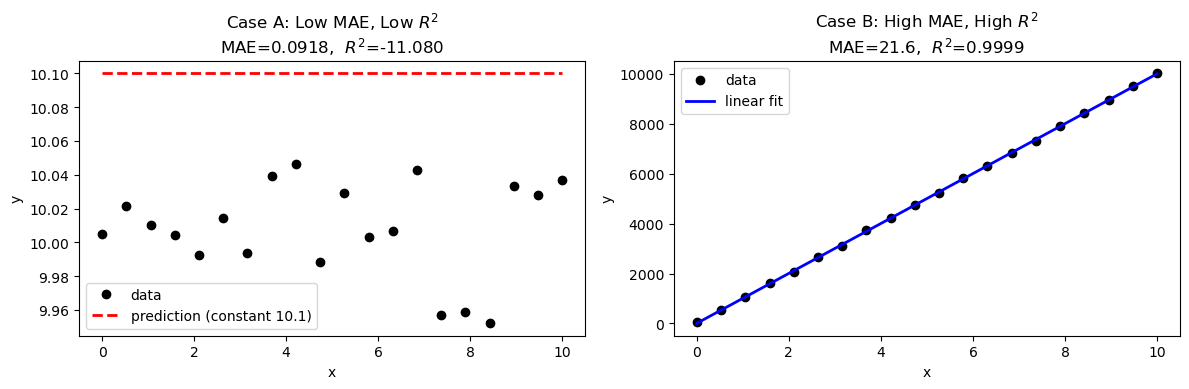

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def metrics(y, y_pred):
    e    = y - y_pred
    mae  = np.mean(np.abs(e))
    mse  = np.mean(e**2)
    ss_res = np.sum(e**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    r2   = 1 - ss_res / ss_tot
    return mae, mse, r2

# ── Case A: Low MAE, Low R² ───────────────────────────────────────────────────
# Data clusters tightly around 10.0 (very low variance).
# The model predicts a constant 10.1 — errors are tiny, but so is the spread,
# so R² is low because the model barely beats the mean.
np.random.seed(0)
x_A  = np.linspace(0, 10, 20)
y_A  = 10.0 + np.random.uniform(-0.05, 0.05, 20)   # near-flat data, range ≈ 0.1
yp_A = np.full_like(y_A, 10.1)                     # constant prediction slightly off

mae_A, mse_A, r2_A = metrics(y_A, yp_A)
print("Case A — Low MAE, Low R²")
print(f"  Data range : {y_A.min():.3f} – {y_A.max():.3f}  (spread ≈ {y_A.max()-y_A.min():.3f})")
print(f"  MAE = {mae_A:.4f}    MSE = {mse_A:.6f}    R² = {r2_A:.4f}")

# ── Case B: High MAE, High R² ─────────────────────────────────────────────────
# Data spans 0–10 000 (huge variance) with a clean linear trend.
# A linear fit tracks it perfectly (R² ≈ 1), but residuals are ~50 units → high MAE.
x_B  = np.linspace(0, 10, 20)
y_B  = 1000 * x_B + np.random.uniform(-50, 50, 20)   # large range, noisy
coeffs_B = np.polyfit(x_B, y_B, 1)
yp_B = np.polyval(coeffs_B, x_B)

mae_B, mse_B, r2_B = metrics(y_B, yp_B)
print("\nCase B — High MAE, High R²")
print(f"  Data range : {y_B.min():.1f} – {y_B.max():.1f}  (spread ≈ {y_B.max()-y_B.min():.1f})")
print(f"  MAE = {mae_B:.4f}    MSE = {mse_B:.2f}    R² = {r2_B:.4f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(x_A, y_A,  'ko', markersize=6, label='data')
ax.plot(x_A, yp_A, 'r--', linewidth=2, label='prediction (constant 10.1)')
ax.set_title(f'Case A: Low MAE, Low $R^2$\nMAE={mae_A:.4f},  $R^2$={r2_A:.3f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

ax = axes[1]
ax.plot(x_B, y_B,  'ko', markersize=6, label='data')
ax.plot(x_B, yp_B, 'b-', linewidth=2, label='linear fit')
ax.set_title(f'Case B: High MAE, High $R^2$\nMAE={mae_B:.1f},  $R^2$={r2_B:.4f}')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend()

plt.tight_layout()
plt.show()

(12.3.4)=
### 12.3.4 Degrees of Freedom in Polynomial Fitting

**Degrees of freedom (DOF)** quantify how much "slack" a model has after satisfying all data constraints:

$$\text{DOF} = N - p$$

where $N$ = number of data points and $p$ = number of model parameters (coefficients).

---

#### 1. Linear fit (degree 1)

$$y = ax + b \qquad (p = 2 \text{ parameters})$$

With $N = 2$ data points:

$$\text{DOF} = 2 - 2 = 0$$

**DOF = 0** means the system is *exactly determined* — one unique line passes through both points, with zero residuals by construction.

---

#### 2. Quadratic fit (degree 2)

$$y = ax^2 + bx + c \qquad (p = 3 \text{ parameters})$$

With $N = 2$ data points:

$$\text{DOF} = 2 - 3 = -1$$

**DOF < 0** means the system is *underdetermined* — more parameters than constraints, so infinitely many quadratic curves pass through those two points. The fit is not unique.

---

#### General rule

| DOF | Condition | Meaning |
|-----|-----------|---------|
| $> 0$ | $N > p$ | Overdetermined — least-squares finds the best compromise |
| $= 0$ | $N = p$ | Exactly determined — perfect interpolation, unique solution |
| $< 0$ | $N < p$ | Underdetermined — infinitely many solutions |

For polynomial fitting of physical data, you almost always want **DOF $\gg 0$**: many more data points than coefficients. This is what makes the fit statistically meaningful — the polynomial is constrained by real data, not just solving a system of equations.

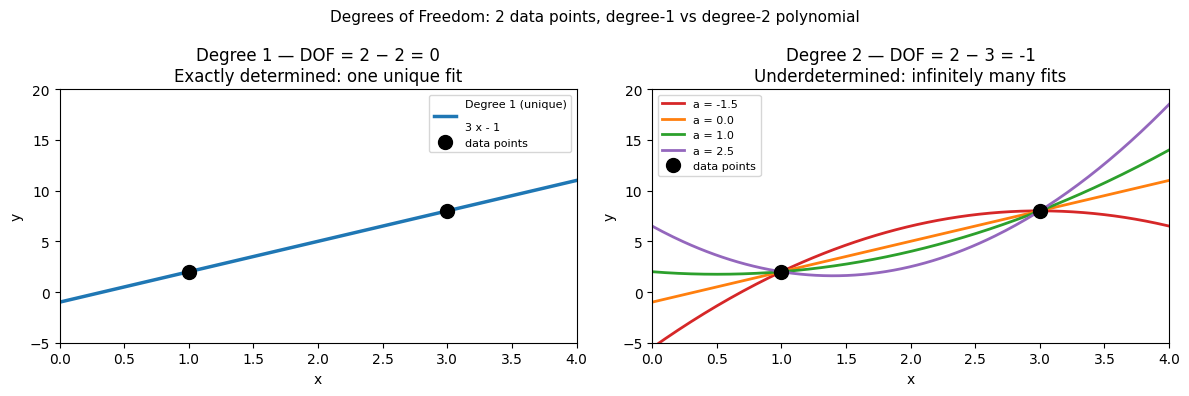

Degree 1 (DOF = 0):
  Unique coefficients: [ 3. -1.]

Degree 2 (DOF = -1) — all four pass exactly through the same two points:
  a=-1.5 → coeffs = [-1.5  9.  -5.5]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+0.0 → coeffs = [ 0.  3. -1.]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+1.0 → coeffs = [ 1. -1.  2.]  | check: p(1.0)=2.0, p(3.0)=8.0
  a=+2.5 → coeffs = [ 2.5 -7.   6.5]  | check: p(1.0)=2.0, p(3.0)=8.0


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Two data points
x_pts = np.array([1.0, 3.0])
y_pts = np.array([2.0, 8.0])

x_fine = np.linspace(0, 4, 200)

# ── Degree 1: DOF = 2 - 2 = 0  (unique solution) ─────────────────────────────
c1 = np.polyfit(x_pts, y_pts, 1)       # one unique line
y1 = np.polyval(c1, x_fine)

# ── Degree 2: DOF = 2 - 3 = -1 (underdetermined — infinitely many solutions) ─
# np.polyfit returns ONE solution (minimum-norm), but infinitely many exist.
# We generate three more by varying the free parameter 'a' manually.
#   y = a*x^2 + bx + c  — with 2 equations and 3 unknowns,
#   'a' is free. Fix a, then solve for b and c.
def quadratic_through_two_points(x_pts, y_pts, a):
    """Given 'a', find b,c so that ax^2 + bx + c passes through both points."""
    x1, x2 = x_pts
    y1, y2 = y_pts
    # y1 = a*x1^2 + b*x1 + c  →  b*x1 + c = y1 - a*x1^2
    # y2 = a*x2^2 + b*x2 + c  →  b*x2 + c = y2 - a*x2^2
    A = np.array([[x1, 1], [x2, 1]])
    rhs = np.array([y1 - a*x1**2, y2 - a*x2**2])
    b, c = np.linalg.solve(A, rhs)
    return np.array([a, b, c])

a_values = [-1.5, 0.0, 1.0, 2.5]   # four choices of the free parameter
colors_q  = ['tab:red', 'tab:orange', 'tab:green', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: degree 1 (unique)
ax = axes[0]
ax.plot(x_fine, y1, 'tab:blue', linewidth=2.5, label=f'Degree 1 (unique)\n{np.poly1d(c1)}')
ax.plot(x_pts, y_pts, 'ko', markersize=10, zorder=5, label='data points')
ax.set_title(f'Degree 1 — DOF = {len(x_pts)} − 2 = {len(x_pts)-2}\nExactly determined: one unique fit')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 4); ax.set_ylim(-5, 20)
ax.legend(fontsize=8)

# Right: degree 2 (infinitely many)
ax = axes[1]
for a_val, col in zip(a_values, colors_q):
    coeffs_q = quadratic_through_two_points(x_pts, y_pts, a_val)
    ax.plot(x_fine, np.polyval(coeffs_q, x_fine), color=col,
            linewidth=2, label=f'a = {a_val}')
ax.plot(x_pts, y_pts, 'ko', markersize=10, zorder=5, label='data points')
ax.set_title(f'Degree 2 — DOF = {len(x_pts)} − 3 = {len(x_pts)-3}\nUnderdetermined: infinitely many fits')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_xlim(0, 4); ax.set_ylim(-5, 20)
ax.legend(fontsize=8)

plt.suptitle('Degrees of Freedom: 2 data points, degree-1 vs degree-2 polynomial', fontsize=11)
plt.tight_layout()
plt.show()

print("Degree 1 (DOF = 0):")
print(f"  Unique coefficients: {c1.round(4)}")
print()
print("Degree 2 (DOF = -1) — all four pass exactly through the same two points:")
for a_val in a_values:
    c = quadratic_through_two_points(x_pts, y_pts, a_val)
    print(f"  a={a_val:+.1f} → coeffs = {c.round(4)}  | check: p({x_pts[0]})={np.polyval(c, x_pts[0]):.1f}, p({x_pts[1]})={np.polyval(c, x_pts[1]):.1f}")


(12.3.5)=
### 12.3.5 Overfitting: When Higher Degree Hurts

Adding more polynomial terms always reduces training error, but can create **overfitting**: the polynomial wiggles between data points and performs poorly outside the training range.

**Why does adding terms always reduce training error?**
With $N$ data points and a degree-$(N-1)$ polynomial, you have exactly enough free coefficients to pass through every point perfectly — residuals become zero by construction. But this is not a good model; it has memorized the noise in the data rather than learned the underlying trend.

**Degrees of freedom** = number of adjustable parameters (coefficients) available to fit the data. A degree-$n$ polynomial has $n+1$ coefficients, so $n+1$ degrees of freedom.

| Degree | Degrees of freedom | Behavior |
|--------|--------------------|----------|
| High ($N-1$) | $N$ — one per data point | Zero training error · High variance · Overfitting risk |
| Low–moderate | $\ll N$ | Nonzero residual · Better generalization · Controlled flexibility |

**The bias-variance tradeoff:**
- A low-degree polynomial is *too rigid* — it misses real structure in the data
- A high-degree polynomial is *too flexible* — it chases every fluctuation and noise spike

The right degree sits in between: flexible enough to capture the physical trend, not so flexible that it fits the noise. A practical warning sign: if the polynomial behaves wildly *between* data points or shoots off just outside the data range, the degree is too high.

$$
\text{If } \deg(p) = N - 1 \text{ and you have } N \text{ points} \implies \text{SS}_{\text{res}} = 0,\quad R^2 = 1 \quad \text{(but the model is useless)}
$$

Here we deliberately use degree 9 (with only 10 data points) to illustrate the problem.

Degree         MAE        R²  Note
------------------------------------------------
     2      0.6030    0.1219  underfit — misses oscillations
     5      0.2763    0.7914  good fit — captures structure
     9      0.1583    0.9236  starts to overfit noise


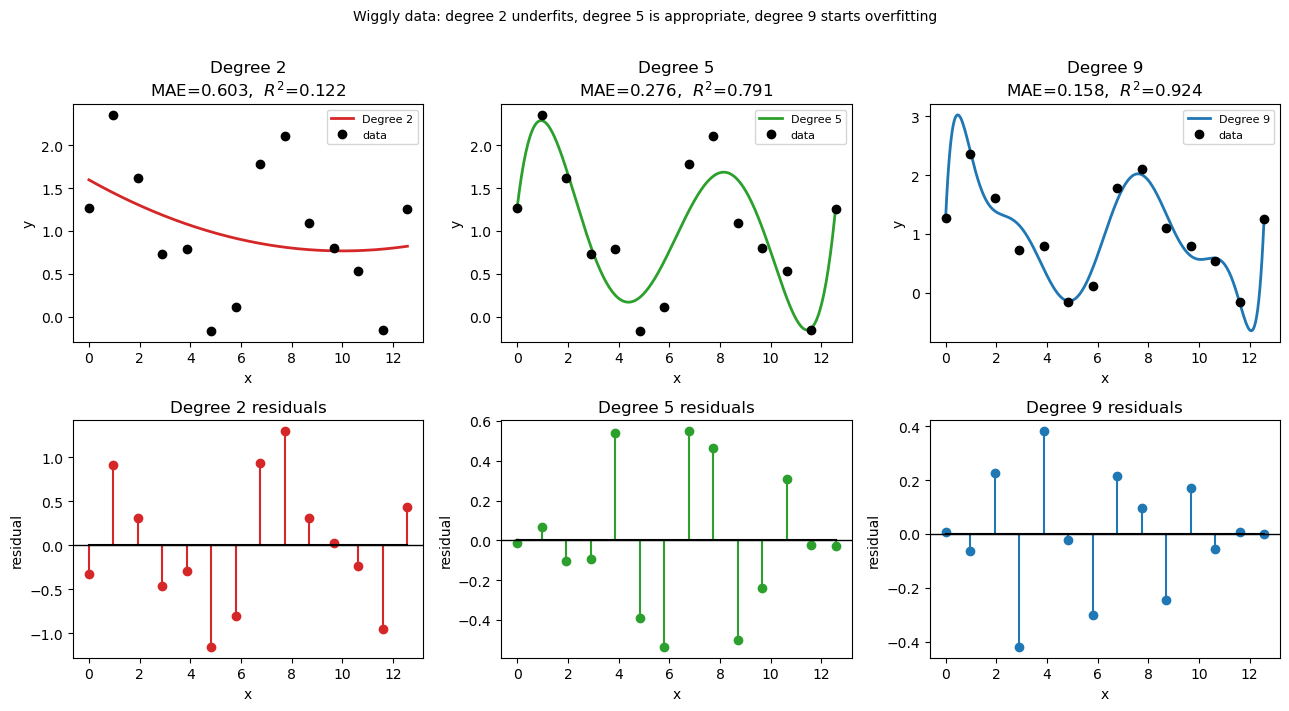

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ── Wiggly dataset: a signal with genuine oscillations + small noise ──────────
# Imagine a periodic reaction yield measured across 12 experimental conditions.
np.random.seed(3)
x_wig = np.linspace(0, 4 * np.pi, 14)
y_wig = np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + np.random.normal(1, 0.15, 14) # np.sin(x_wig) + 0.5 * np.sin(2 * x_wig) + 


x_fine = np.linspace(0, 4 * np.pi, 300)

# Fit with degree 2, 5, and 9
degs   = [2, 5, 9]
colors = ['tab:red', 'tab:green', 'tab:blue']
fits_w = {d: np.polyfit(x_wig, y_wig, d) for d in degs}

# ── Metrics ───────────────────────────────────────────────────────────────────
SS_tot_w = np.sum((y_wig - np.mean(y_wig))**2)
print(f"{'Degree':>6}  {'MAE':>10}  {'R²':>8}  {'Note'}")
print("-" * 48)
notes = {2: 'underfit — misses oscillations',
         5: 'good fit — captures structure',
         9: 'starts to overfit noise'}
for d in degs:
    pred = np.polyval(fits_w[d], x_wig)
    res  = y_wig - pred
    mae  = np.mean(np.abs(res))
    r2   = 1 - np.sum(res**2) / SS_tot_w
    print(f"{d:>6}  {mae:>10.4f}  {r2:>8.4f}  {notes[d]}")

# ── Plot: fits ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for col, (d, color) in enumerate(zip(degs, colors)):
    y_pred_fine = np.polyval(fits_w[d], x_fine)
    y_pred_data = np.polyval(fits_w[d], x_wig)
    residuals   = y_wig - y_pred_data
    mae  = np.mean(np.abs(residuals))
    r2   = 1 - np.sum(residuals**2) / SS_tot_w

    # Top row: fit vs data
    ax = axes[0, col]
    ax.plot(x_fine, y_pred_fine, color=color, linewidth=2, label=f'Degree {d}')
    ax.plot(x_wig, y_wig, 'ko', markersize=6, zorder=5, label='data')
    ax.set_title(f'Degree {d}\nMAE={mae:.3f},  $R^2$={r2:.3f}')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8)

    # Bottom row: residuals
    ax = axes[1, col]
    ax.stem(x_wig, residuals, linefmt=color, markerfmt='o', basefmt='k-')
    ax.axhline(0, color='k', linewidth=1)
    ax.set_title(f'Degree {d} residuals')
    ax.set_xlabel('x'); ax.set_ylabel('residual')

plt.suptitle('Wiggly data: degree 2 underfits, degree 5 is appropriate, degree 9 starts overfitting',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# ── Overfitting demonstration ─────────────────────────────────────────────────


(12.4)=
## 12.4 Summary

| Concept | Tool / Formula | When to use |
|---------|---------------|-------------|
| **Polynomial evaluation** | `np.polyval(coeffs, x)` | Evaluate a stored coefficient array at $x$ |
| **Polynomial object** | `np.poly1d(coeffs)` | Callable; `.integ()` returns antiderivative |
| **Least-squares fit** | `np.polyfit(x, y, deg)` | Fit noisy or tabulated data; keep degree small |
| **Residuals** | $e_i = y_i - p(x_i)$ | Signed error at each data point |
| **MAE** | $\frac{1}{N}\sum\|e_i\|$ | Average error in original units; easy to interpret |
| **MSE** | $\frac{1}{N}\sum e_i^2$ | Penalizes large errors; units are $y^2$ |
| **$R^2$** | $1 - \sum e_i^2 / \sum(y_i-\bar{y})^2$ | Fraction of variance explained; 1 = perfect |